In [ ]:
pip install spacy

In [4]:
!python -m spacy download en_core_web_md

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 12.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [5]:
from numpy import dot
from numpy.linalg import norm
import spacy
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
nlp = spacy.load('en_core_web_md')

In [2]:
all_datasets = pd.read_csv('outputWithDBTerms.csv', header = 0)
print(all_datasets.head())

                                                name  \
0  Longitudinal Evaluation of Chicagos Community ...   
1          National Mortality Followback Survey 1993   
2  Uniform Crime Reporting Program Data [United S...   
3  Enhanced Services for the Hard-to-Employ Cente...   
4  Arab Barometer: Public Opinion Survey Conducte...   

                                            abstract  \
0  The purpose of this study was to evaluate the ...   
1  The National Mortality Followback Survey (NMFS...   
2  These data provide information on the number o...   
3  The Enhanced Services for the Hard-to-Employ (...   
4  The Arab Barometer is a multicountry social su...   

                                         icpsr_terms  \
0  citizen participation  |  community involvemen...   
1  accidents  |  causes of death  |  death record...   
2  arrest records  |  arrests  |  crime rates  | ...   
3  child support  |  conviction records  |  crimi...   
4  Arab Israeli conflict  |  democracy  |  eco

In [7]:
#ICPSR compared to AI selections

def compute_similarity(i):
    try:
        group1 = all_datasets.loc[all_datasets['name'] == i, 'icpsr_terms'].values[0]
        group2 = all_datasets.loc[all_datasets['name'] == i, 'model_selected_terms_no_hal'].values[0]

        if not group1 or not group2:
            raise ValueError("One of the word groups is None or empty")

        def average_vector(words):
            return sum(nlp(word).vector for word in words) / len(words)

        vec1 = average_vector(group1)
        vec2 = average_vector(group2)

        similarity = dot(vec1, vec2) / (norm(vec1) * norm(vec2))
        return similarity

    except Exception as e:
        print(f"⚠️ Skipping {i} due to error: {e}")
        return 0.0

In [8]:
names = all_datasets['name'].tolist()
icpsr_vs_ai = []

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(compute_similarity, i): i for i in names}

    for future in tqdm(as_completed(futures), total=len(futures)):
        result = future.result()
        icpsr_vs_ai.append(result)

  4%|▍         | 20/500 [01:31<24:35,  3.07s/it] 

⚠️ Skipping Restricted dataset from the Bureau of Labor Statistics (temporary test) due to error: 'float' object is not iterable


 17%|█▋        | 83/500 [04:49<24:06,  3.47s/it]

⚠️ Skipping Restricted dataset from the Agency for Healthcare Research and Quality (temporary test) due to error: 'float' object is not iterable


 31%|███▏      | 157/500 [08:34<09:29,  1.66s/it]

...

 96%|█████████▌| 480/500 [25:06<00:43,  2.15s/it]

⚠️ Skipping (Restricted) Commercial VSGI Tracker (TRK) due to error: 'float' object is not iterable


 97%|█████████▋| 487/500 [25:24<00:28,  2.18s/it]

⚠️ Skipping Sierra Leone Threshold - Water Sector Reform: Administrative Data Set & Focus Group Discussions (Restricted) due to error: 'float' object is not iterable


100%|██████████| 500/500 [25:54<00:00,  3.11s/it]


In [9]:
all_datasets['icpsr_vs_ai'] = icpsr_vs_ai

In [10]:
#ICPSR vs DB

def compute_similarity_db(i):
    try:
        group1 = all_datasets.loc[all_datasets['name'] == i, 'icpsr_terms'].values[0]
        group2 = all_datasets.loc[all_datasets['name'] == i, 'database_selected_terms'].values[0]

        if not group1 or not group2:
            raise ValueError("One of the word groups is None or empty")

        def average_vector(words):
            return sum(nlp(word).vector for word in words) / len(words)

        vec1 = average_vector(group1)
        vec2 = average_vector(group2)

        similarity = dot(vec1, vec2) / (norm(vec1) * norm(vec2))
        return similarity

    except Exception as e:
        print(f"⚠️ Skipping {i} due to error: {e}")
        return 0.0

In [11]:
icpsr_vs_db = []

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(compute_similarity_db, i): i for i in names}

    for future in tqdm(as_completed(futures), total=len(futures)):
        result = future.result()
        icpsr_vs_db.append(result)

  0%|          | 2/500 [00:47<2:43:28, 19.70s/it]

⚠️ Skipping Longitudinal Evaluation of Chicagos Community Policing Program 1993-2001 due to error: 'float' object is not iterable


  2%|▏         | 10/500 [01:51<34:53,  4.27s/it] 

⚠️ Skipping Restricted dataset from the Bureau of Labor Statistics (temporary test) due to error: 'float' object is not iterable


 15%|█▍        | 73/500 [09:07<51:06,  7.18s/it]  

...

 94%|█████████▍| 470/500 [52:34<03:14,  6.50s/it]

⚠️ Skipping (Restricted) Commercial VSGI Tracker (TRK) due to error: 'float' object is not iterable


 95%|█████████▌| 477/500 [53:20<02:44,  7.14s/it]

⚠️ Skipping Sierra Leone Threshold - Water Sector Reform: Administrative Data Set & Focus Group Discussions (Restricted) due to error: 'float' object is not iterable


100%|██████████| 500/500 [54:46<00:00,  6.57s/it]


In [12]:
all_datasets['icpsr_vs_db'] = icpsr_vs_db

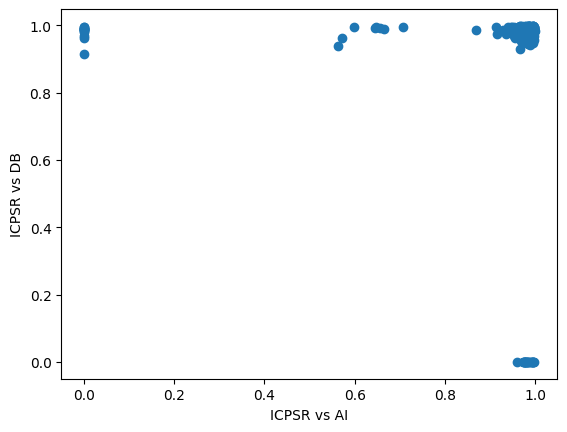

In [13]:
import matplotlib.pyplot as plt

plt.scatter(all_datasets['icpsr_vs_ai'], all_datasets['icpsr_vs_db'])

plt.xlabel('ICPSR vs AI')
plt.ylabel('ICPSR vs DB')

plt.show()

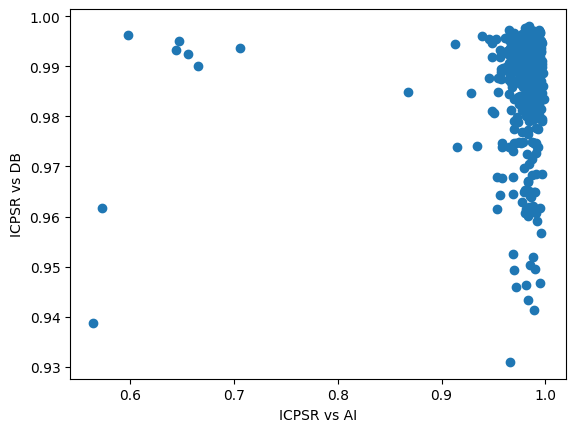

In [15]:
all_datasets_filtered = all_datasets[(all_datasets != 0).all(axis=1)]

plt.scatter(all_datasets_filtered['icpsr_vs_ai'], all_datasets_filtered['icpsr_vs_db'])

plt.xlabel('ICPSR vs AI')
plt.ylabel('ICPSR vs DB')

plt.show()

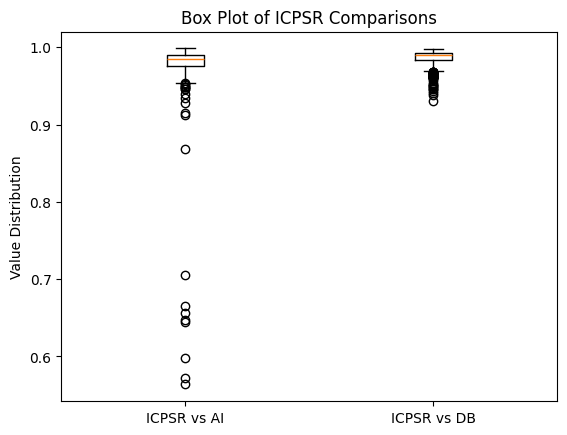

In [29]:
plt.boxplot([all_datasets_filtered['icpsr_vs_ai'], all_datasets_filtered['icpsr_vs_db']],
            tick_labels=['ICPSR vs AI', 'ICPSR vs DB'])

plt.ylabel('Value Distribution')
plt.title('Box Plot of ICPSR Comparisons')
plt.show()

In [27]:
#AI Cosine

# Mean
mean_val_ai = all_datasets_filtered['icpsr_vs_ai'].mean()
# Median
median_val_ai = all_datasets_filtered['icpsr_vs_ai'].median()
# Mode 
mode_val_ai = all_datasets_filtered['icpsr_vs_ai'].mode()

#DB Cosine
# Mean
mean_val_db = all_datasets_filtered['icpsr_vs_db'].mean()
# Median
median_val_db  = all_datasets_filtered['icpsr_vs_db'].median()
# Mode 
mode_val_db  = all_datasets_filtered['icpsr_vs_db'].mode()

print(f"AI Mean: {mean_val_ai}")
print(f"DB Mean: {mean_val_db }")
print(" ")
print(f"AI Median: {median_val_ai}")
print(f"DB Median: {median_val_db }")
print(" ")
print(f"AI Mode: {mode_val_ai.tolist()}")
print(f"DB Mode: {mode_val_db .tolist()}")

AI Mean: 0.9754387899111676
DB Mean: 0.9863311961132993
 
AI Median: 0.9845083951950073
DB Median: 0.9900365471839905
 
AI Mode: [0.9844934940338135]
DB Mode: [0.9951269030570984]
